HTML(value='<style>.cell-output-ipywidget-background {\n   background-color: transparent !important;\n}\n.jp-O…

Checkbox(value=True, description='Enable Drag')

Checkbox(value=False, description='Enable Temperature')

FloatSlider(value=-0.04999999999999999, description='Target angle', layout=Layout(width='500px'), max=0.1, min…

FloatSlider(value=0.5, description='Thrust angle', layout=Layout(width='500px'), max=3.141592653589793, step=0…

...

IntSlider(value=15, description='Flight time', layout=Layout(width='500px'), max=5000)

FloatSlider(value=0.2, description='Velocity', layout=Layout(width='500px'))

Button(description='Run', style=ButtonStyle())

Optimization time: 21.709 s
Optimized t_flight: 258.05 s
Optimized velocity: 1875.19 km / s
Distance to target: 0.001 km


/home/jcl5m1/.local/lib/python3.10/site-packages/scipy/integrate/_ode.py:431: UserWarning: dopri5: step size becomes too small
  self._y, self.t = mth(self.f, self.jac or (lambda: None),
/home/jcl5m1/.local/lib/python3.10/site-packages/scipy/integrate/_ode.py:431: UserWarning: dopri5: step size becomes too small
  self._y, self.t = mth(self.f, self.jac or (lambda: None),


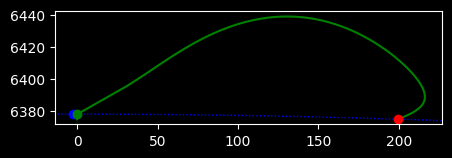

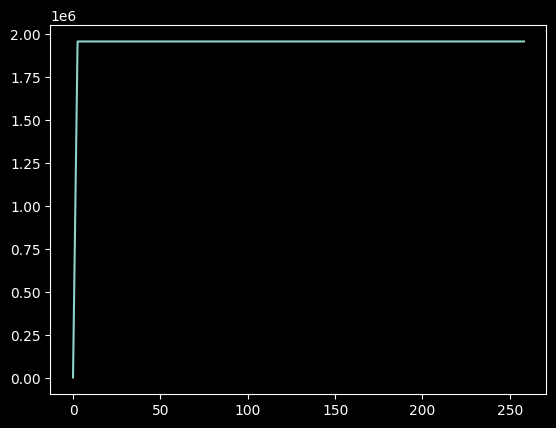

In [4]:
# interactive trajectory intercept minimizer
import importlib

import matplotlib.pyplot as plt
from IPython.display import clear_output
from ipywidgets import interact, IntSlider, FloatSlider, Layout, interactive, Button, HTML, Checkbox
import numpy as np
from orbitengine.body import Body
import orbitengine.engine as oe
import astropy.units as u
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize
import time
importlib.reload(oe)
#importlib.reload(Body)

width = '500px'
target_angle_slider = FloatSlider(min=-.5, max=.1, value=-0.05,step=0.01, layout=Layout(width=width), description='Target angle')
thrust_angle_slider = FloatSlider(min=0, max=np.pi, value=0.5,step=0.01, layout=Layout(width=width), description='Thrust angle')
t_flight_slider = IntSlider(min=0, max=5000,value=15, layout=Layout(width=width), description='Flight time')
velocity_slider = FloatSlider(min=0, max=100, step=0.1, value=0.17, layout=Layout(width=width), description='Velocity')
mass_slider = FloatSlider(min=10, max=10000, step=1, value=5000, layout=Layout(width=width), description='Mass')
style_html = HTML('<style>' + open('notebook_darkmode.css').read() + '</style>')
# Create the checkbox
drag_checkbox = Checkbox(value=False, description='Enable Drag')
temp_checkbox = Checkbox(value=False, description='Enable Temperature')


def target_dist(x, thrust_angle, state_init, state_target, acc_params=None):
    velocity, t_flight = x
    rot = R.from_euler('z', thrust_angle)
    v = np.array([velocity, 0, 0])*u.km/u.s

    state_maneuver = Body.State(state_init.position, 
                     rot.apply(v)*u.km/u.s, 
                     state_init.mass)
    sm = state_maneuver.propagate(oe.EARTH_K, t_flight*u.s, acc_params=acc_params)
    st = state_target.propagate(oe.EARTH_K, t_flight*u.s)

    dp = np.linalg.norm(st.position - sm.position).value
    return dp


def f(target_angle, 
      thrust_angle, 
      t_flight, 
      velocity, 
      mass, 
      enable_drag, 
      enable_temp):

    # Define a function that creates a plot
    state_init = Body.State(
    np.array([0,oe.EARTH_RADIUS_KM, 0])*u.km, 
    oe.V_ZERO, 
    mass*u.kg, 
    parent_axis_angle=oe.EARTH_AXIS_ANGLE_Z)

    rot_target = R.from_euler('z', target_angle)
    state_target = Body.State(rot_target.apply(state_init.position)*u.km, 
                              oe.V_ZERO, 
                              mass*u.kg,
                              parent_axis_angle=oe.EARTH_AXIS_ANGLE_Z)

    x0 = [velocity, t_flight]
    ts_start = time.time()
    acc_params = oe.AccParams(enable_drag=enable_drag)

    bounds = [(0, 100), (1, 5000)]
    res = minimize(target_dist, 
                   x0, 
#                   bounds=bounds,
                   args=(thrust_angle, 
                         state_init, 
                         state_target, 
                         acc_params))
    ts_stop = time.time()
    print(f"Optimization time: {ts_stop - ts_start:.3f} s")

    # original maneuver
    rot = R.from_euler('z', thrust_angle)
    v = np.array([velocity, 0, 0])*u.km/u.s
    state_guess_maneuver = Body.State(state_init.position, rot.apply(v)*u.km/u.s, state_init.mass)

    ts1 = np.linspace(0, t_flight*u.s, 100)
    sgm = state_guess_maneuver.propagate(oe.EARTH_K, ts1, acc_params=acc_params)

    plt.style.use('dark_background')
    fig, axs = plt.subplots(1, 1, figsize=(5, 5))

    # plot original inital guess maneuver trajectory
    axs.plot([s.position[0].value for s in sgm], [s.position[1].value for s in sgm], color='b')
    axs.plot(sgm[-1].position[0].value, sgm[-1].position[1].value, 'bo')

    # optimized maneuver
    velocity, t_flight = res.x
    print(f"Optimized t_flight: {t_flight*u.s:.2f}")
    print(f"Optimized velocity: {velocity*u.km/u.s:.2f}")
    rot = R.from_euler('z', thrust_angle)
    v = np.array([velocity, 0, 0])*u.km/u.s
    state_optimized_maneuver = Body.State(state_init.position, rot.apply(v)*u.km/u.s, state_init.mass, T=oe.TEMP_EARTH)

    #plot optimized trajectory
    ts2 = np.linspace(0, t_flight*u.s, 100)
    acc_params.enable_temp = enable_temp
    sm2 = state_optimized_maneuver.propagate(oe.EARTH_K, ts2, acc_params=acc_params)
    axs.plot([s.position[0].value for s in sm2], [s.position[1].value for s in sm2],color='g')

    st_final = state_target.propagate(oe.EARTH_K, t_flight*u.s).position.value
    axs.plot(st_final[0], st_final[1], 'ro')
    axs.add_artist(plt.Line2D((0, st_final[0]), (0, st_final[1]), color='r', linestyle='dotted'))

    axs.plot(state_init.position[0].value, state_init.position[1].value, 'go')

    dr = np.linalg.norm(st_final - sm2[-1].position.value)*u.km
    print(f"Distance to target: {dr:.3f}")
 
    circle = plt.Circle((0, 0), oe.EARTH_RADIUS_KM, color='b', fill=False, linestyle='dotted')
    axs.add_artist(circle)
    axs.add_artist(plt.Line2D((0, state_init.position[0].value), (0, state_init.position[1].value), color='g', linestyle='dotted'))
    axs.set_aspect('equal', adjustable='box')
    plt.show()

    plt.plot(ts2, [s.temperature.value for s in sm2])
    plt.show()



# Define a function to be run when the button is clicked
def on_button_clicked(b):

    clear_output(wait=True)
    display(style_html,
            drag_checkbox,
            temp_checkbox,
            target_angle_slider,
            thrust_angle_slider, 
            mass_slider, 
            t_flight_slider, 
            velocity_slider, 
            button)
    

    # Get the current values of the sliders
    target_angle = target_angle_slider.value
    thrust_angle = thrust_angle_slider.value
    t_flight = t_flight_slider.value
    velocity = velocity_slider.value
    mass = mass_slider.value
    enable_drag = drag_checkbox.value
    enable_temp = temp_checkbox.value
    # Call your function with these values
    f(target_angle, thrust_angle, t_flight, velocity, mass, enable_drag, enable_temp)

# Set this function to be called when the button is clicked
button = Button(description="Run")

button.on_click(on_button_clicked)

# Display the button
display(style_html,
        drag_checkbox,
        temp_checkbox,
        target_angle_slider,
        thrust_angle_slider, 
        mass_slider, 
        t_flight_slider, 
        velocity_slider, 
        button)

In [2]:
#oe.EARTH_ATMOSPHERE_RHO0.to(u.kg/u.m**3)
# oe.STEFAN_BOLTZMANN_COEF

# sb = (5.67e-8*u.W/u.m**2/u.Kelvin**4).to(u.J/u.s/u.km**2/u.Kelvin**4)
# sb

# v_mag = np.linalg.norm(v)
# drag_coef = self.atmosphere_lateral_drag_coefficient if self.lateral else self.atmosphere_axial_drag_coefficient
# cross_section = self.lateral_cross_section if self.lateral else self.axial_cross_section
# rho = self.atmosphere_rho0 * np.exp(-altitude/self.atmosphere_scale_height)
# drag_force = -0.5 * rho * v_mag**2 * cross_section * drag_coef * (v / v_mag)
# dT_drag = np.linalg.norm(drag_force)*v_mag/(self.specific_heat*mass)
# return drag_force, dT_drag

from scipy.spatial.transform import Rotation as R


#oe.FALCON9_AXIAL_CROSS_SECTION_AREA
#oe.FALCON9_AXIAL_DRAG_COEF
r = np.array([0+oe.EARTH_RADIUS_KM, 0, 0])*u.km
alt = np.linalg.norm(r) - oe.EARTH_RADIUS_KM*u.km
v = np.array([3.0,0,0])*u.km/u.s
v_mag = np.linalg.norm(v)
rho = oe.EARTH_ATMOSPHERE_RHO0*np.exp(-alt/oe.EARTH_ATMOSPHERE_SCALE_HEIGHT)
crosssection = oe.FALCON9_AXIAL_CROSS_SECTION_AREA
drag_coef = oe.FALCON9_AXIAL_DRAG_COEF
v_atm = R.from_rotvec(oe.EARTH_AXIS_ANGLE_Z).apply(np.cross(oe.EARTH_AXIS_ANGLE_Z, r))


print(f"v_atm: {np.linalg.norm(v_atm)}")
print(f"rv: {2*np.pi *oe.EARTH_RADIUS_KM/(3600*24)}")
# drag_force = -0.5 * rho * v_mag**2 * crosssection * drag_coef*v/v_mag
# drag_force/oe.FALCON9_DRY_MASS


v_atm: 0.46382852092270976
rv: 0.46382852092270976
